In [12]:
#TASK 1
import pandas as pd
df=pd.read_csv("/content/customer_churn_nn.csv")
print("Shape:",df.shape)
print(df.info())


Shape: (2000, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   customer_id                   2000 non-null   object 
 1   region                        2000 non-null   object 
 2   plan_type                     2000 non-null   object 
 3   contract_type                 2000 non-null   object 
 4   payment_method                2000 non-null   object 
 5   tenure_months                 2000 non-null   int64  
 6   monthly_charges_inr           2000 non-null   float64
 7   avg_login_days_per_month      2000 non-null   int64  
 8   support_tickets_last_90_days  2000 non-null   int64  
 9   payment_delay_days            2000 non-null   int64  
 10  data_usage_gb                 2000 non-null   float64
 11  satisfaction_score            2000 non-null   float64
 12  last_complaint_days_ago       2000 non-null 

In [14]:
print(df.isnull().sum())
print("Statistical Summary:\n",df.describe())

customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64
Statistical Summary:
        tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           4

In [15]:
print(df['churn'].value_counts())

churn
0    1969
1      31
Name: count, dtype: int64


In [21]:
#TASK 2

X=df.drop(['customer_id','churn'],axis=1)
y=df['churn']
X=pd.get_dummies(X,drop_first=True)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
print(X_scaled)


[[ 0.32835124 -0.20107534 -0.94438559 ... -0.49060655 -0.48982201
  -0.50624244]
 [-0.7335868   0.66930633  0.72250406 ... -0.49060655 -0.48982201
   1.97533814]
 [ 3.30177775 -0.08750418 -0.94438559 ... -0.49060655 -0.48982201
  -0.50624244]
 ...
 [-0.45040332  1.0316306  -0.01833579 ...  2.0382932  -0.48982201
  -0.50624244]
 [-1.51234136  2.27732845  1.83376382 ... -0.49060655 -0.48982201
  -0.50624244]
 [ 0.39914711  0.62486434 -0.57396567 ...  2.0382932  -0.48982201
  -0.50624244]]


In [22]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=42)

In [25]:
#Task 3

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential()

#Input layer
model.add(Input(shape=(X_train.shape[1],)))

#Hidden layer 1
model.add(Dense(16, activation='relu'))

#Hidden layer 2
model.add(Dense(8, activation='relu'))

#Output
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 545 (2.13 KB)

 Trainable params: 545 (2.13 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
#Task 4

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

train_loss, train_acc = model.evaluate(X_train, y_train)
print("Training Loss:", train_loss)
print("Training Accuracy:", train_acc)

test_loss, test_acc = model.evaluate(X_test, y_test)
print("Testing Loss:", test_loss)
print("Testing Accuracy:", test_acc)

y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n",cm)

from sklearn.metrics import classification_report
print("Classification Report:\n",classification_report(y_test, y_pred))

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9867 - loss: 0.0472 - val_accuracy: 0.9781 - val_loss: 0.1105
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9867 - loss: 0.0462 - val_accuracy: 0.9781 - val_loss: 0.1113
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9867 - loss: 0.0454 - val_accuracy: 0.9781 - val_loss: 0.1123
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9867 - loss: 0.0445 - val_accuracy: 0.9781 - val_loss: 0.1131
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9867 - loss: 0.0436 - val_accuracy: 0.9781 - val_loss: 0.1135
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9867 - loss: 0.0427 - val_accuracy: 0.9781 - val_loss: 0.1146
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9867 - loss: 0.0418 - val_accuracy: 0.9781 - val_loss: 0.1155
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9867 - loss: 0.0409 - val_accuracy: 0.9781 - val_

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The neural network achieved a training accuracy of 98.5% and testing accuracy of 98.25%, with low loss values, indicating stable learning. The training and testing performance were similar, suggesting no significant overfitting. However, the confusion matrix revealed that the model predicted all customers as non-churn. Out of 7 actual churn customers in the test set, none were correctly identified. This occurred due to severe class imbalance in the dataset, where churn cases were very limited. Therefore, accuracy alone was misleading, and additional metrics such as precision, recall, and F1-score showed poor performance for the churn class.

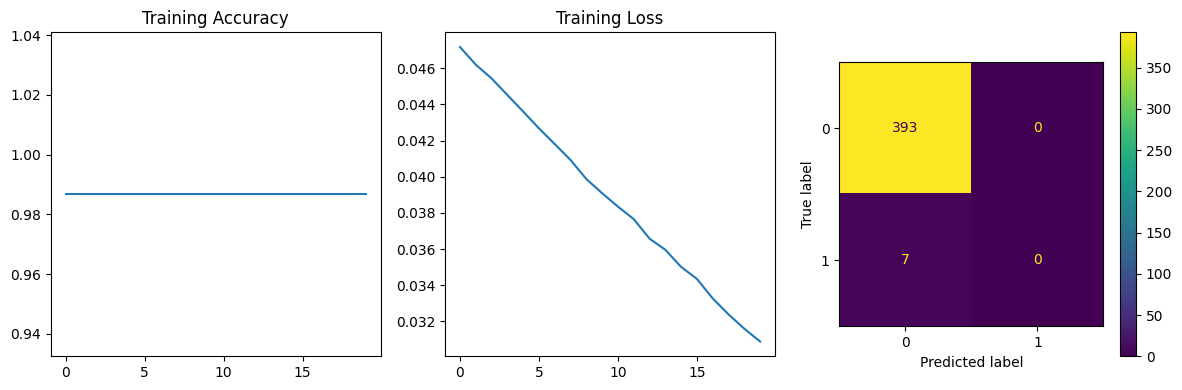

['evaluation_outputs.png']

In [31]:
import os

os.makedirs("results", exist_ok=True)
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os

os.makedirs("results", exist_ok=True)

plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,3,1)
plt.plot(history.history['accuracy'])
plt.title("Training Accuracy")

# Loss
plt.subplot(1,3,2)
plt.plot(history.history['loss'])
plt.title("Training Loss")

# Confusion Matrix
plt.subplot(1,3,3)
ConfusionMatrixDisplay(cm).plot(ax=plt.gca())

plt.tight_layout()

# Save image
plt.savefig("results/evaluation_outputs.png")

plt.show()
os.listdir("results")

In [30]:
#Task 5

#Baseline Model
model1 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model1.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32
)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(test_acc)
print(test_loss)

from sklearn.metrics import confusion_matrix
y_pred = (model.predict(X_test) > 0.5).astype(int)
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))

#Increasing neurons and handle imbalance
model2 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
class_weight = {
    0:1,
    1:63
}
model2.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    class_weight=class_weight
)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(test_acc)
print(test_loss)

y_pred = (model.predict(X_test) > 0.5).astype(int)
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))

#More layer and lower batch size
model3 = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
model3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model3.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=16,
    class_weight=class_weight
)
test_loss, test_acc = model.evaluate(X_test, y_test)
print(test_acc)
print(test_loss)

y_pred = (model.predict(X_test) > 0.5).astype(int)
print("Confusion Matrix:\n",confusion_matrix(y_test, y_pred))

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.5738 - loss: 0.6781
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8956 - loss: 0.3584
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9750 - loss: 0.2177
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - loss: 0.1479
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9850 - loss: 0.1130
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - loss: 0.0952
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - loss: 0.0860
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - loss: 0.0804
Epoch 9/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - loss: 0.0766
Epoch 10/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - loss: 0.0737
Epoch 11/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - loss: 0.0709
Epoch 12/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - lo

Task 6  
Q1. In a neural network, weights determine how important each input feature is for making predictions. Features that influence customer churn more strongly receive higher weight values.

Bias helps shift the neuron’s output so the model can fit the data more flexibly.

A neuron calculates:

z=w
1
​
 x
1
​
 +w
2
​
 x
2
​
 +…+w
n
​
 x
n
​
 +b
+⋯+b

Where:

x = input features,
w = weights,
b = bias

During training, the model updates these values to reduce prediction error.    


Q2. An activation function introduces non-linearity into the neural network. Without activation functions, multiple layers would behave like a single linear model, limiting the network’s ability to learn complex relationships.

In this project, ReLU was used in hidden layers:  
f(x)=max(0,x)  
ReLU helps the network learn complex customer behavior patterns such as:  
a. low satisfaction  
b. frequent complaints  
c. payment delays  

which may lead to churn.

The output layer used sigmoid because this is a binary classification problem.    
    
    
Q3. The learning rate controls how much weights change during training.  
If the learning rate is too high, the model may overshoot the best solution and training becomes unstable.  
If the learning rate is too low, learning becomes very slow and training may take many epochs to converge.  

Using the Adam optimizer in Keras helped automatically adjust learning efficiently.  


Q4. The model did not show strong overfitting, because training and testing accuracy were very close:  

Training Accuracy ≈ 98.5%  
Testing Accuracy ≈ 98.25%  

This indicates the model generalized consistently on unseen data.
However, the confusion matrix showed that the model failed to identify churn customers.  
This suggests the main issue was class imbalance, not overfitting or underfitting. The model learned the majority class (retained customers) well, but struggled to learn the minority churn class.  